In [3]:
import numpy as np
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv('train.csv')
df.shape

(1460, 81)

In [6]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [7]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [58]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [59]:
df['TotalBsmtSF'].corr(df['1stFlrSF'])

np.float64(0.8195299750050336)

In [60]:
check_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt']
df[check_features].corr()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,TotRmsAbvGrd,YearBuilt
OverallQual,1.000000,0.593007,0.600671,0.537808,0.550600,0.427452,0.572323
GrLivArea,0.593007,1.000000,0.467247,0.454868,0.630012,0.825489,0.199010
GarageCars,0.600671,0.467247,1.000000,0.434585,0.469672,0.362289,0.537850
TotalBsmtSF,0.537808,0.454868,0.434585,1.000000,0.323722,0.285573,0.391452
FullBath,0.550600,0.630012,0.469672,0.323722,1.000000,0.554784,0.468271
TotRmsAbvGrd,0.427452,0.825489,0.362289,0.285573,0.554784,1.000000,0.095589
YearBuilt,0.572323,0.199010,0.537850,0.391452,0.468271,0.095589,1.000000


In [61]:
selected_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'SalePrice']
df_new = df[selected_features]
df_new.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,SalePrice
0,7,1710,2,856,2,2003,208500
1,6,1262,2,1262,2,1976,181500
2,7,1786,2,920,2,2001,223500
3,7,1717,3,756,1,1915,140000
4,8,2198,3,1145,2,2000,250000


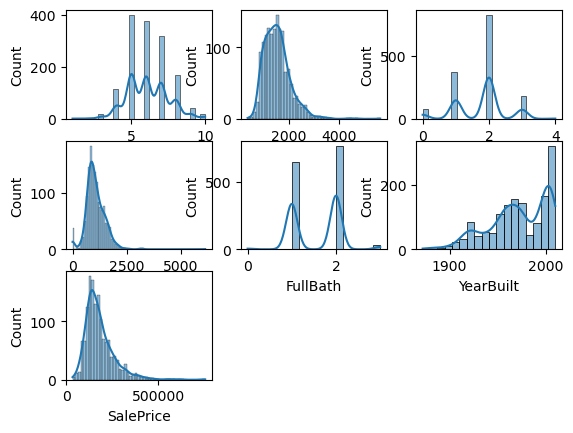

In [77]:
def plotting(var,num):
    plt.subplot(3,3,num)
    sns.histplot(df[var],kde=True,)


plotting('OverallQual',1)
plotting('GrLivArea',2)
plotting('GarageCars',3)
plotting('TotalBsmtSF',4)
plotting('FullBath',5)
plotting('YearBuilt',6)
plotting('SalePrice',7)

In [81]:
df_new['GrLivArea'].value_counts().sort_values(ascending=True)

GrLivArea
804      1
2601     1
2210     1
1738     1
974      1
        ..
848     10
1456    10
894     11
1040    14
864     22
Name: count, Length: 861, dtype: int64

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

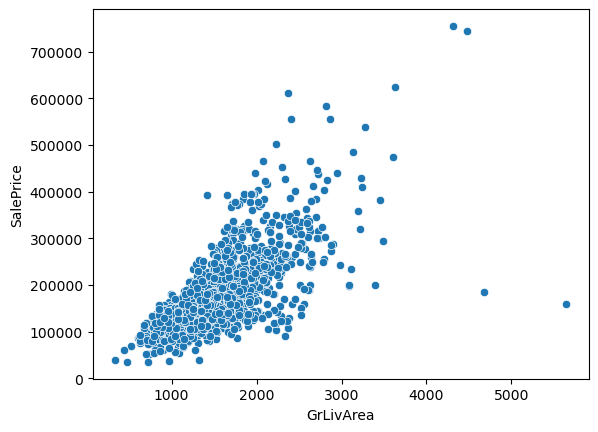

In [86]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_new)

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

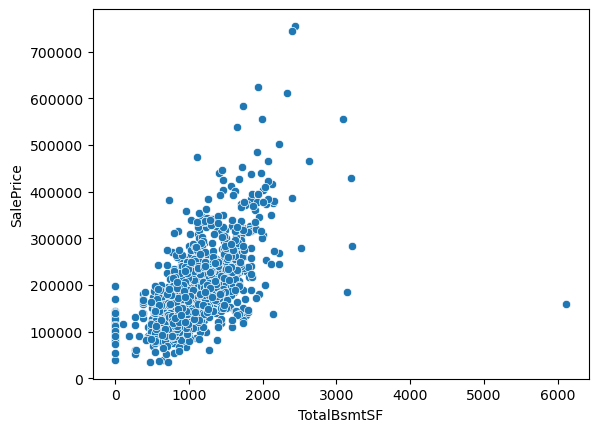

In [88]:
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df_new)

In [102]:
df_new[(df_new['GrLivArea']>4000) & (df_new['SalePrice']<300000)]

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,SalePrice
523,10,4676,3,3138,3,2007,184750
1298,10,5642,2,6110,2,2008,160000


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

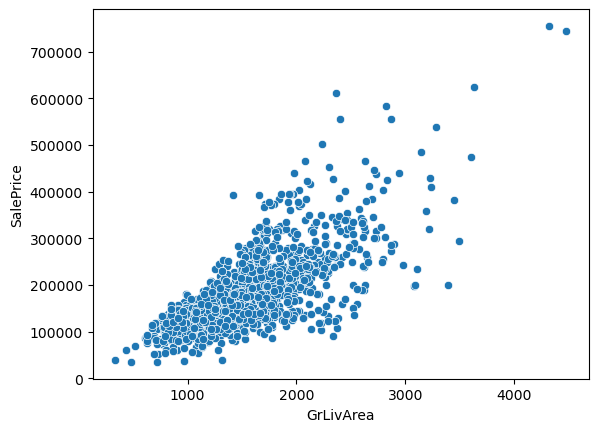

In [118]:
df_new=df_new[~((df_new['GrLivArea']>4000) & (df_new['SalePrice']<300000))]
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_new)

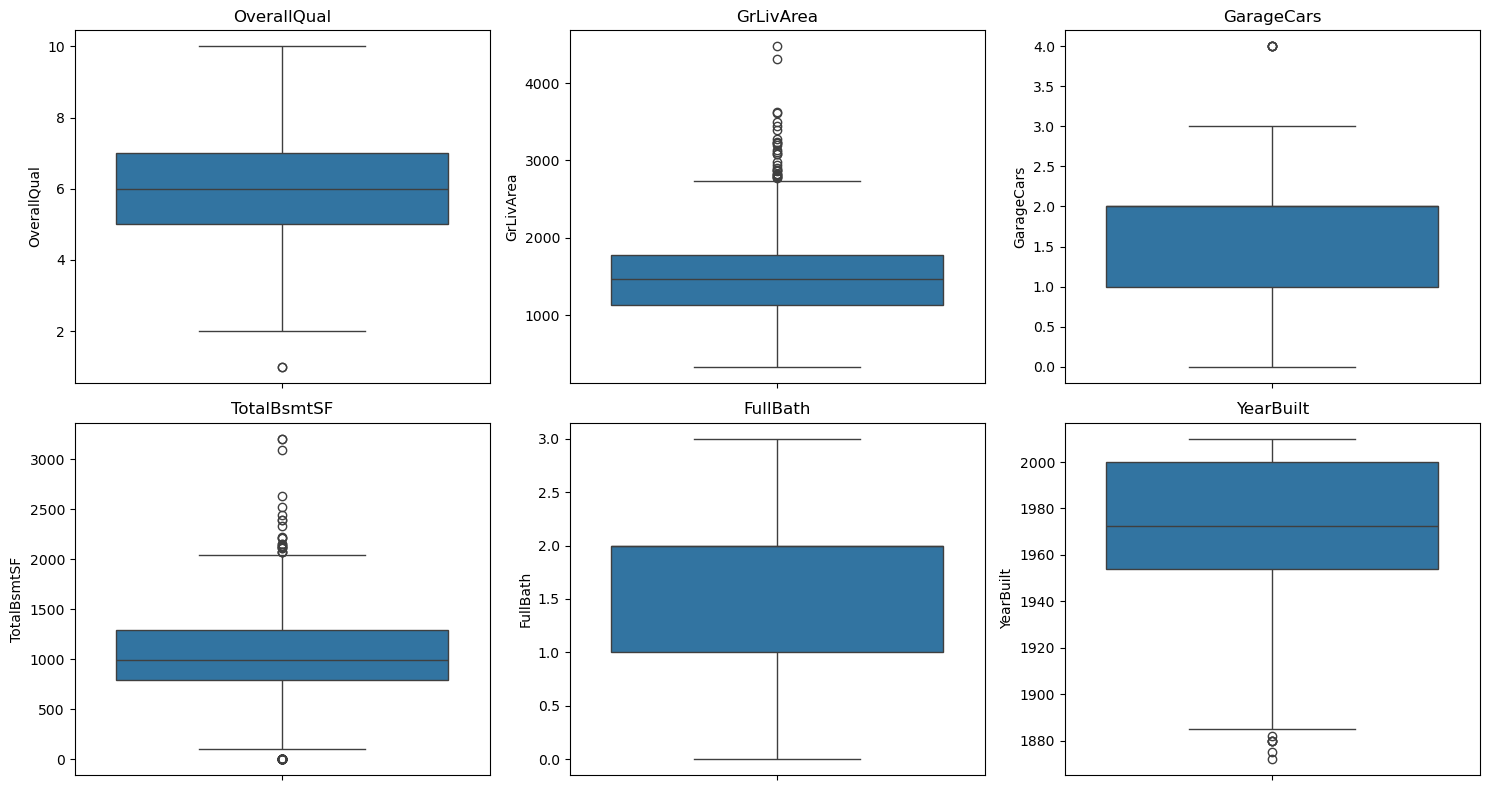

In [117]:
plt.figure(figsize=(15,8))
for i, col in enumerate(['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','FullBath','YearBuilt'], 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df_new[col])
    plt.title(col)
plt.tight_layout()
plt.show()

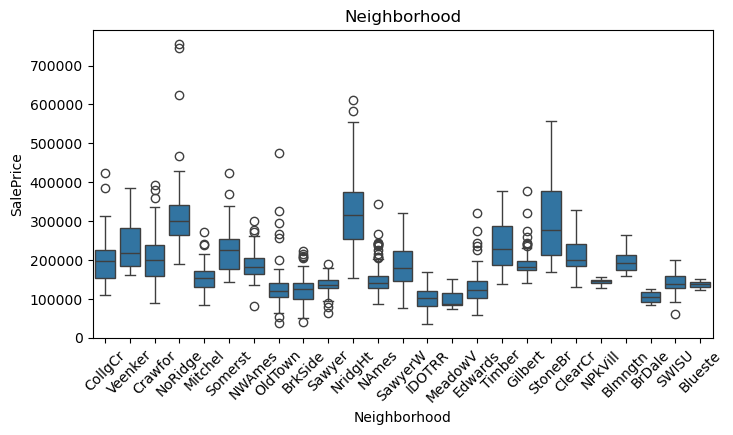

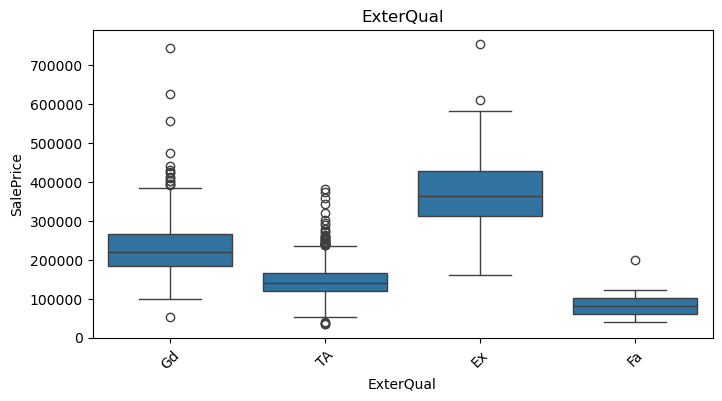

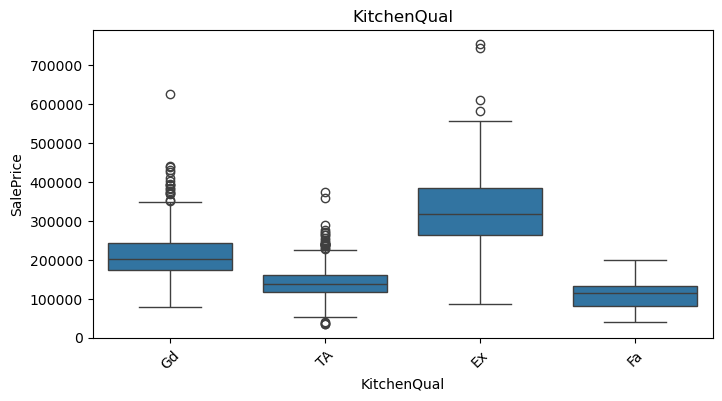

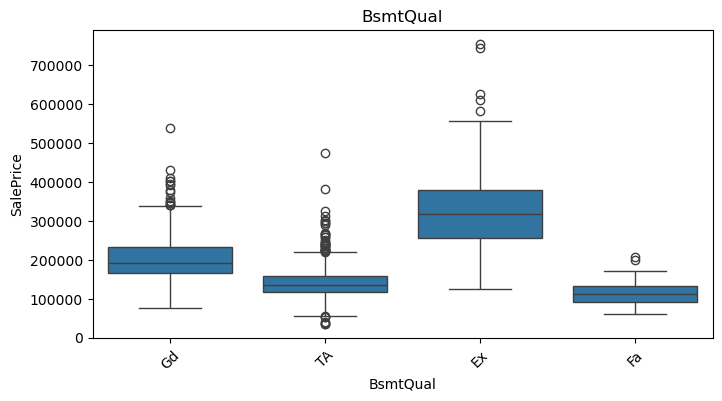

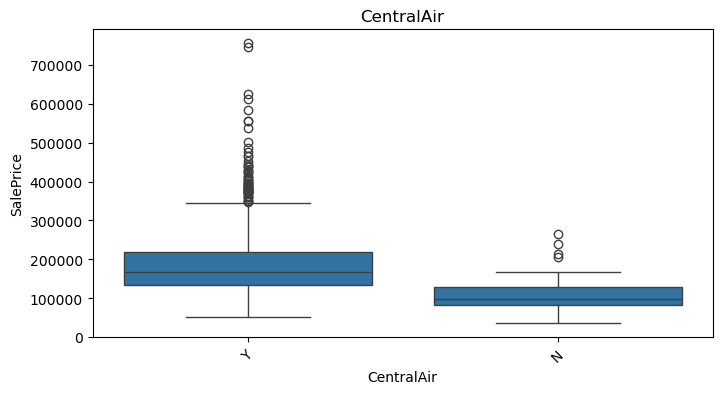

In [119]:
for col in ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'CentralAir']:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y='SalePrice', data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

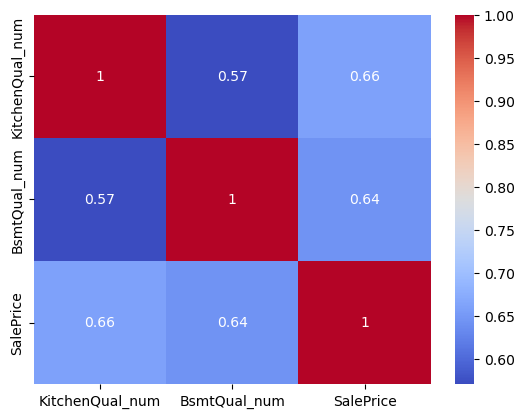

In [120]:

quality_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1}

df['KitchenQual_num'] = df['KitchenQual'].map(quality_map)
df['BsmtQual_num'] = df['BsmtQual'].map(quality_map)


corr = df[['KitchenQual_num', 'BsmtQual_num', 'SalePrice']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [123]:
numeric_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
categorical_features = ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'CentralAir']

df_new = df[numeric_features + categorical_features + ['SalePrice']]
df_new.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,Neighborhood,ExterQual,KitchenQual,BsmtQual,CentralAir,SalePrice
0,7,1710,2,856,2,2003,CollgCr,Gd,Gd,Gd,Y,208500
1,6,1262,2,1262,2,1976,Veenker,TA,TA,Gd,Y,181500
2,7,1786,2,920,2,2001,CollgCr,Gd,Gd,Gd,Y,223500
3,7,1717,3,756,1,1915,Crawfor,TA,Gd,TA,Y,140000
4,8,2198,3,1145,2,2000,NoRidge,Gd,Gd,Gd,Y,250000


In [131]:
df_new['BsmtQual']
df_new['BsmtQual'] = df_new['BsmtQual'].fillna('None')

In [134]:
df_encode=pd.get_dummies(df_new,drop_first=True)

In [139]:
df_encode=df_encode.astype(int)
df_encode

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,ExterQual_Gd,ExterQual_TA,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_None,BsmtQual_TA,CentralAir_Y
0,7,1710,2,856,2,2003,208500,0,0,0,...,1,0,0,1,0,0,1,0,0,1
1,6,1262,2,1262,2,1976,181500,0,0,0,...,0,1,0,0,1,0,1,0,0,1
2,7,1786,2,920,2,2001,223500,0,0,0,...,1,0,0,1,0,0,1,0,0,1
3,7,1717,3,756,1,1915,140000,0,0,0,...,0,1,0,1,0,0,0,0,1,1
4,8,2198,3,1145,2,2000,250000,0,0,0,...,1,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,953,2,1999,175000,0,0,0,...,0,1,0,0,1,0,1,0,0,1
1456,6,2073,2,1542,2,1978,210000,0,0,0,...,0,1,0,0,1,0,1,0,0,1
1457,7,2340,1,1152,2,1941,266500,0,0,0,...,0,0,0,1,0,0,0,0,1,1
1458,5,1078,1,1078,1,1950,142125,0,0,0,...,0,1,0,1,0,0,0,0,1,1


In [144]:
df_encode['Neighborhood_BrkSide'].value_counts()

Neighborhood_BrkSide
0    1402
1      58
Name: count, dtype: int64

In [148]:
from sklearn.preprocessing  import StandardScaler

In [152]:
scaler= StandardScaler()
numeric_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
df_encode[numeric_features]=scaler.fit_transform(df_encode[numeric_features])

In [153]:
df_encode

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,ExterQual_Gd,ExterQual_TA,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_None,BsmtQual_TA,CentralAir_Y
0,0.651479,0.370333,0.311725,-0.459303,0.789741,1.050994,208500,0,0,0,...,1,0,0,1,0,0,1,0,0,1
1,-0.071836,-0.482512,0.311725,0.466465,0.789741,0.156734,181500,0,0,0,...,0,1,0,0,1,0,1,0,0,1
2,0.651479,0.515013,0.311725,-0.313369,0.789741,0.984752,223500,0,0,0,...,1,0,0,1,0,0,1,0,0,1
3,0.651479,0.383659,1.650307,-0.687324,-1.026041,-1.863632,140000,0,0,0,...,0,1,0,1,0,0,0,0,1,1
4,1.374795,1.299326,1.650307,0.199680,0.789741,0.951632,250000,0,0,0,...,1,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-0.071836,0.250402,0.311725,-0.238122,0.789741,0.918511,175000,0,0,0,...,0,1,0,0,1,0,1,0,0,1
1456,-0.071836,1.061367,0.311725,1.104925,0.789741,0.222975,210000,0,0,0,...,0,1,0,0,1,0,1,0,0,1
1457,0.651479,1.569647,-1.026858,0.215641,0.789741,-1.002492,266500,0,0,0,...,0,0,0,1,0,0,0,0,1,1
1458,-0.795151,-0.832788,-1.026858,0.046905,-1.026041,-0.704406,142125,0,0,0,...,0,1,0,1,0,0,0,0,1,1


In [163]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
model=LinearRegression()
from sklearn.metrics import r2_score

In [160]:
x=df_encode.drop('SalePrice',axis=1)
y=df_encode['SalePrice']

In [161]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [162]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [164]:

model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [169]:
pred=model.predict(x_test)
pred

array([134849.27162675, 354617.57323183, 114189.78151152, 171199.85002403,
       320346.46750838,  62933.01583682, 224037.40282088, 151654.71006313,
        62748.86517164, 121066.23577136, 148623.0859251 , 108192.232497  ,
       105986.76683875, 229744.1931804 , 182703.85059902, 129188.15928124,
       202473.10337357, 125572.66465132, 118877.65370002, 206235.84087052,
       169631.13338111, 214490.02444233, 186041.99618331, 115757.37546984,
       203521.22794558, 170667.83000945, 193493.86051548, 117006.26333622,
       178796.34914264, 237503.97705869, 127892.36630011, 255519.56203723,
       284313.41034768, 106292.89339482, 239383.41177505, 138226.31411673,
       160149.13365847, 216961.6418106 , 324141.73644222,  86451.09171379,
       144550.00144869, 216415.59629313, 117927.67629251, 364077.36797852,
       131214.74590403, 164995.62334767, 115141.11384406, 118513.783579  ,
       391193.14389056, 140101.27669344, 116587.87167511, 181630.81094699,
       108585.11893575, 2

In [168]:
y_test

892     154500
1105    325000
413     115000
522     159000
1036    315500
         ...  
479      89471
1361    260000
802     189000
651     108000
722     124500
Name: SalePrice, Length: 292, dtype: int64

In [171]:
r2 = r2_score(y_test, pred)
print("R² Score:", r2)

R² Score: 0.8522362134886974


In [173]:
n = x_test.shape[0]  # rows in test set
k = x_test.shape[1]  # number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R² Score:", adjusted_r2)

Adjusted R² Score: 0.8280029525008438


In [174]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': pred})
comparison['Difference'] = comparison['Actual'] - comparison['Predicted']
comparison.head(10)

,Actual,Predicted,Difference
892,154500,134849.271627,19650.728373
1105,325000,354617.573232,-29617.573232
413,115000,114189.781512,810.218488
522,159000,171199.850024,-12199.850024
1036,315500,320346.467508,-4846.467508
614,75500,62933.015837,12566.984163
218,311500,224037.402821,87462.597179
1160,146000,151654.710063,-5654.710063
649,84500,62748.865172,21751.134828
887,135500,121066.235771,14433.764229


In [116]:
df.select_dtypes(include='object').columns


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [106]:
df[['Condition1', 'Condition2']].value_counts()

Condition1  Condition2
Norm        Norm          1260
Feedr       Norm            76
Artery      Norm            45
RRAn        Norm            22
PosN        Norm            17
RRAe        Norm            11
PosA        Norm             8
RRAn        Feedr            4
RRNn        Norm             4
Feedr       RRNn             2
PosN        PosN             2
RRNe        Norm             2
Artery      Artery           2
Feedr       RRAn             1
            RRAe             1
            Feedr            1
Artery      PosA             1
RRNn        Feedr            1
Name: count, dtype: int64

<Axes: xlabel='Condition1', ylabel='SalePrice'>

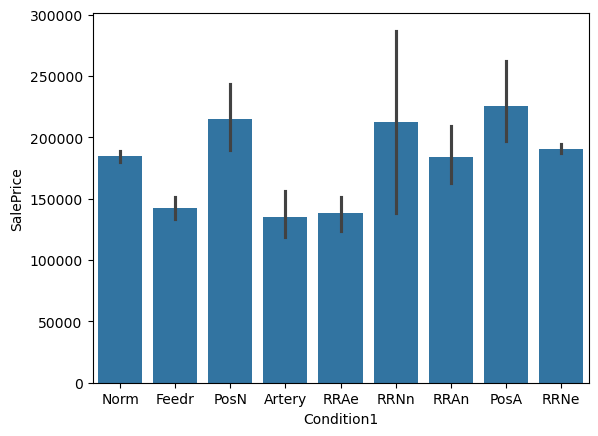

In [107]:
sns.barplot(x=df['Condition1'],y=df['SalePrice'])

<Axes: xlabel='Condition2', ylabel='SalePrice'>

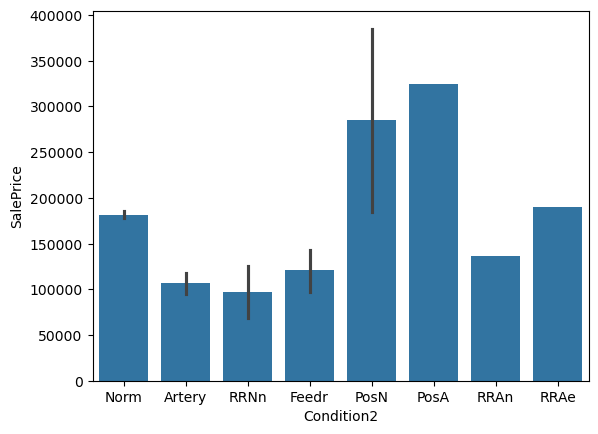

In [108]:
sns.barplot(x=df['Condition2'],y=df['SalePrice'])

In [109]:
df['FireplaceQu'].value_counts()

FireplaceQu
None    690
Gd      380
TA      313
Fa       33
Ex       24
Po       20
Name: count, dtype: int64

In [110]:
df[['FireplaceQu','Fireplaces']].head()


,FireplaceQu,Fireplaces
0,None,0
1,TA,1
2,TA,1
3,Gd,1
4,TA,1


In [111]:
df['FireplaceQu']=df['FireplaceQu'].fillna('None')


In [112]:
df['FireplaceQu'].isnull().sum()

np.int64(0)

In [113]:
df.groupby('MasVnrArea')['MasVnrType'].value_counts()


MasVnrArea  MasVnrType
0.0         None          859
            BrkFace         1
            Stone           1
1.0         None            2
11.0        BrkFace         1
                         ... 
1115.0      BrkFace         1
1129.0      BrkFace         1
1170.0      BrkFace         1
1378.0      BrkFace         1
1600.0      BrkFace         1
Name: count, Length: 401, dtype: int64

In [114]:
condition = df['MasVnrType'].isna() & (df['MasVnrArea'] == 0)

df[condition][['MasVnrType', 'MasVnrArea']].head(20)


,MasVnrType,MasVnrArea


In [115]:
df[['MasVnrArea', 'MasVnrType']].head(20)
df[df['MasVnrType'].isnull()]['MasVnrArea'].value_counts()

Series([], Name: count, dtype: int64)

In [45]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')

In [46]:
df = df.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature'], axis=1)

np.int64(0)